# Contact Force Regression — ResNet18 Training

**Training strategy (two phases):**
| Phase | Backbone | Learning rate | Epochs |
|---|---|---|---|
| 1 — Warmup | Frozen | 1 × 10⁻⁴ | up to 1000 (early stopping) |
| 2 — Fine-tuning | Unfrozen | 1 × 10⁻⁵ | up to 1000 (early stopping) |

**Input:** 224 × 224 greyscale images (converted to 3-channel for ImageNet normalisation)  
**Output:** `[force_magnitude, force_angle]` (MSE loss on each component independently)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import math
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm.notebook import tqdm  # specific for Jupyter

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


## Configuration

Edit the paths and settings in this cell before running the notebook.

In [33]:
# ── Data ─────────────────────────────────────────────────────────────────────
LABEL_PATH = 'sample_data/labels.npy'
IMG_DIR    = 'sample_data'
BATCH_SIZE = 32

# ── Model checkpoints ────────────────────────────────────────────────────────
WARMUP_MODEL_PATH    = 'contact_force_regression_warmup.pth'
FINETUNED_MODEL_PATH = 'contact_force_regression_finetuned.pth'


## Custom dataset and callbacks

`Dataset` loads images from a directory (sorted numerically) and pairs them with labels from a `.npy` file of shape `(N, 2)` — `[force_magnitude, force_angle]` per row.

`EarlyStopping` monitors validation loss, saves the best checkpoint, and halts training if no improvement exceeds `min_delta` for `patience` consecutive epochs.

In [63]:
class ContactForceDataset(Dataset):
    def __init__(self, npy_file, img_dir, transform=None):
        """
        Args:
            npy_file (string): Path to the .npy file containing labels [N, 2].
            img_dir (string): Directory with all the images.
            transform (callable, optional): Transform to be applied on a sample.
        """
        # 1. List Images
        self.img_dir = Path(img_dir)
        self.img_paths = sorted(list(self.img_dir.glob("*.png")))

        # 2. Load Labels — filenames are 1-indexed, subtract 1 to get the row index.
        all_labels = np.load(npy_file).astype(np.float32)
        indices = [int(p.stem) - 1 for p in self.img_paths]
        self.labels = all_labels[indices]

        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = Image.open(img_path).convert('L')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label


class EarlyStopping:
    def __init__(self, patience, min_delta, path):
        """
        Args:
            patience (int): How many epochs to wait after last time validation loss improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        print(f'Validation loss decreased. Saving model to {self.path} ...')


In [ ]:
def train_model(model, optimizer, train_loader, val_loader, epochs, stopper, device, label="Epoch"):
    history = []
    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        train_loss = train_force = train_angle = 0.0
        loop = tqdm(train_loader, desc=f"{label} {epoch+1}/{epochs}", leave=False)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            lf = F.mse_loss(outputs[:, 0], labels[:, 0])
            la = F.mse_loss(outputs[:, 1], labels[:, 1])
            loss = lf + la
            loss.backward()
            optimizer.step()
            train_loss += loss.item(); train_force += lf.item(); train_angle += la.item()
            loop.set_postfix(loss=loss.item())

        n = len(train_loader)
        avg_tl, avg_tf, avg_ta = train_loss / n, train_force / n, train_angle / n

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = val_force = val_angle = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                lf = F.mse_loss(outputs[:, 0], labels[:, 0])
                la = F.mse_loss(outputs[:, 1], labels[:, 1])
                val_loss += (lf + la).item(); val_force += lf.item(); val_angle += la.item()

        n = len(val_loader)
        avg_vl, avg_vf, avg_va = val_loss / n, val_force / n, val_angle / n

        print(f"{label} {epoch+1}: "
              f"Train {avg_tl:.4f} [F:{avg_tf:.4f} A:{avg_ta:.4f}] | "
              f"Val {avg_vl:.4f} [F:{avg_vf:.4f} A:{avg_va:.4f}]")

        history.append({'epoch': epoch + 1,
                        'train_loss': avg_tl, 'train_force': avg_tf, 'train_angle': avg_ta,
                        'val_loss':   avg_vl, 'val_force':   avg_vf, 'val_angle':   avg_va})

        stopper(avg_vl, model)
        if stopper.early_stop:
            print(f"{label}: early stopping triggered.")
            break

    return history


## Load and split data

Reads the label file (`labels.npy`, shape `(N, 2)`) and the matching image directory, applies ImageNet normalisation after converting each greyscale image to 3 channels, then splits the dataset 70 / 15 / 15 into train, validation, and test sets.

Total: 501 | Train: 350 | Val: 75 | Test: 76
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32, 2])


Text(0.5, 1.0, 'tensor([0.0947, 0.1907])')

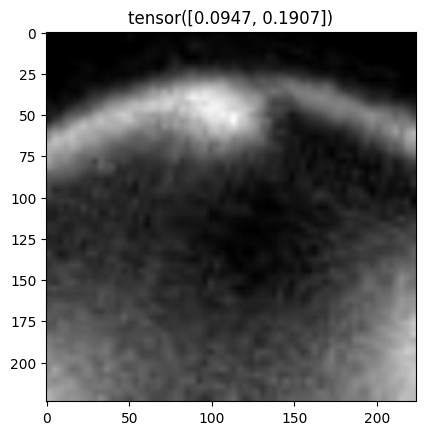

In [104]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

dataset = ContactForceDataset(npy_file=LABEL_PATH, img_dir=IMG_DIR, transform=data_transform)

total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

print(f"Total: {total_size} | Train: {train_size} | Val: {val_size} | Test: {test_size}")

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")  # [BATCH_SIZE, 3, 224, 224]
print(f"Batch label shape: {labels.shape}")  # [BATCH_SIZE, 2]

random_index = torch.randint(0, images.shape[0], (1,)).item()
plt.imshow(images[random_index][0], cmap='gray')
plt.title(labels[random_index])

## Model architecture

Loads a pretrained ResNet18 and replaces its classification head with a regression head:

```
Linear(512 → 256) → ReLU → Dropout(0.2) → Linear(256 → 2)
```

All backbone parameters are frozen for the warmup phase; only the new head is trained.

In [105]:
def get_model(device, output_dim=2):   
    # 1. Load Pre-trained Model
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # 2. Freeze the 'Body' (Feature Extractor)
    for param in model.parameters():
        param.requires_grad = False
        
    # 3. Replace the 'Head' (Classifier -> Regressor)
    num_ftrs = model.fc.in_features  # 512
    
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.2),            # Drop 20% of neurons to prevent overfitting
        nn.Linear(256, output_dim)  # Output: [Force, Angle]
    )
    
    # Move to GPU/CPU
    model = model.to(device)
    return model

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(device)


########## DEFINE LOSS AND OPTIMIZER #########################
optimizer = optim.Adam(model.fc.parameters(), lr=1e-4)

print("Model Structure (Final Layer):")
print(model.fc)

Model Structure (Final Layer):
Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=2, bias=True)
)


## Phase 1 — Warmup training (frozen backbone)

Trains only the regression head with Adam (lr = 1 × 10⁻⁴).  
Loss = MSE(force) + MSE(angle), monitored separately per component.  
Best checkpoint is saved; training halts early if validation loss does not improve for `PATIENCE` epochs.

In [ ]:
EPOCHS    = 100
PATIENCE  = 20
MIN_DELTA = 0.001
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

stopper = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, path=WARMUP_MODEL_PATH)
history = train_model(model, optimizer, train_loader, val_loader, EPOCHS, stopper, DEVICE, label="Warmup")

## Phase 2 — Fine-tuning (full network)

Reloads the best warmup checkpoint, unfreezes all layers, and creates a new Adam optimiser with a much lower learning rate (1 × 10⁻⁵) to adapt the pretrained backbone without overwriting learned features.

In [107]:
model.load_state_dict(torch.load(WARMUP_MODEL_PATH))
print("Loaded best weights from Phase 1.")

for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

Loaded best weights from Phase 1.


### Fine-tuning loop

In [ ]:
FT_EPOCHS    = 200
FT_PATIENCE  = 20
FT_MIN_DELTA = 0.0001
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

stopper    = EarlyStopping(patience=FT_PATIENCE, min_delta=FT_MIN_DELTA, path=FINETUNED_MODEL_PATH)
ft_history = train_model(model, optimizer, train_loader, val_loader, FT_EPOCHS, stopper, DEVICE, label="Fine-Tune")

## Training history — loss curves

Plots train and validation MSE loss on a log scale for both phases concatenated on the epoch axis. Dashed ideal line shows convergence reference.

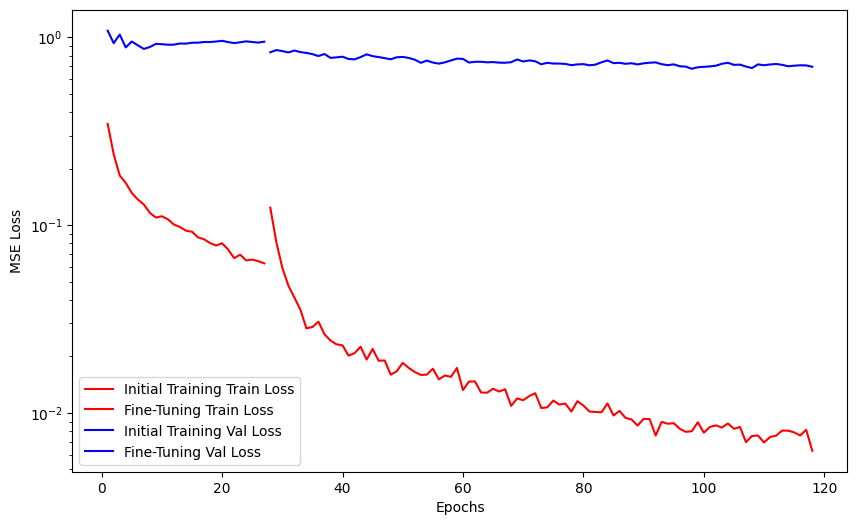

In [109]:
epochs = [h['epoch'] for h in history]
val_losses = [h['val_loss'] for h in history]
train_losses = [h['train_loss'] for h in history]
ft_epochs = [h['epoch'] for h in ft_history]
ft_train_losses = [h['train_loss'] for h in ft_history]
ft_val_losses = [h['val_loss'] for h in ft_history]
plt.figure(figsize=(10,6))
plt.plot(epochs, train_losses,'r', label='Initial Training Train Loss')
plt.plot([e + epochs[-1] for e in ft_epochs], ft_train_losses, 'r', label='Fine-Tuning Train Loss')
plt.plot(epochs, val_losses,'b', label='Initial Training Val Loss')
plt.plot([e + epochs[-1] for e in ft_epochs], ft_val_losses, 'b', label='Fine-Tuning Val Loss')

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')  
plt.legend()
plt.yscale('log')

## Evaluation on the test set

Loads the fine-tuned model weights, runs inference on the held-out test set, and plots predicted vs. true values for force magnitude (log scale) and force angle.

In [101]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(DEVICE)
model.load_state_dict(torch.load(FINETUNED_MODEL_PATH))
model.eval()

test_preds = []
test_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        test_preds.append(outputs.cpu().numpy())
        test_labels.append(labels.cpu().numpy())

test_preds  = np.concatenate(test_preds,  axis=0)
test_labels = np.concatenate(test_labels, axis=0)

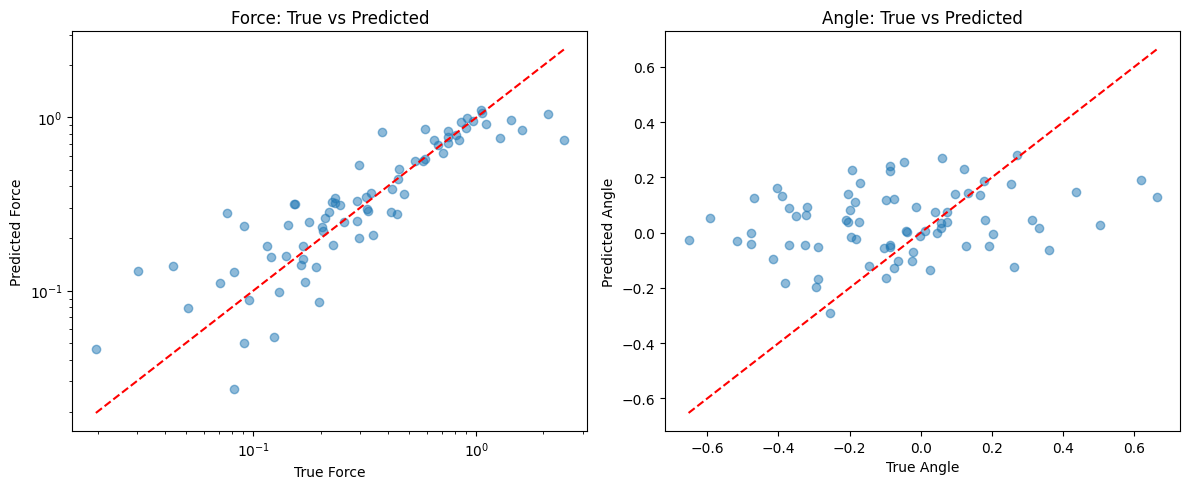

In [110]:
#plot predicted vs true for force and angle
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.scatter(test_labels[:, 0], test_preds[:, 0], alpha=0.5)
plt.plot([test_labels[:, 0].min(), test_labels[:, 0].max()], [test_labels[:, 0].min(), test_labels[:, 0].max()], 'r--')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('True Force')    
plt.ylabel('Predicted Force')
plt.title('Force: True vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(test_labels[:, 1], test_preds[:, 1], alpha=0.5)
plt.plot([test_labels[:, 1].min(), test_labels[:, 1].max()], [test_labels[:, 1].min(), test_labels[:, 1].max()], 'r--')
plt.xlabel('True Angle')    
plt.ylabel('Predicted Angle')
plt.title('Angle: True vs Predicted')

plt.tight_layout()
plt.show()